In [5]:
import sklearn
print(sklearn.__version__)

1.9.0


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 设置随机种子，保证结果可复现
np.random.seed(42)

# 如果需要显示中文，可取消下面两行注释（Windows/本地环境可能需要）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ========== 1. 生成模拟数据 ==========
# 假设真实关系大致为：房价 = 3.5 * 面积 + 20 + 噪声
n_samples = 200
area = np.random.uniform(30, 120, n_samples)  # 面积：30~120平方米
noise = np.random.normal(0, 15, n_samples)    # 噪声
price = 3.5 * area + 20 + noise               # 房价

df = pd.DataFrame({'面积': area, '价格': price})
print("数据前5行：")
print(df.head(200))

数据前5行：
             面积          价格
0     63.708611  232.779767
1    115.564288  427.958812
2     95.879455  359.974179
3     83.879264  302.862151
4     44.041678  202.132489
..          ...         ...
195   61.428862  213.889059
196   95.336011  342.899376
197  110.739923  404.388025
198  109.837778  409.095837
199  100.188799  392.791140

[200 rows x 2 columns]



描述性统计：
               面积          价格
count  200.000000  200.000000
mean    73.560561  278.473177
std     26.540229   93.679398
min     30.496991  114.093766
25%     50.572417  194.421614
50%     74.503763  272.690764
75%     98.117365  360.758154
max    118.819824  454.644866

相关系数矩阵：
          面积        价格
面积  1.000000  0.987896
价格  0.987896  1.000000


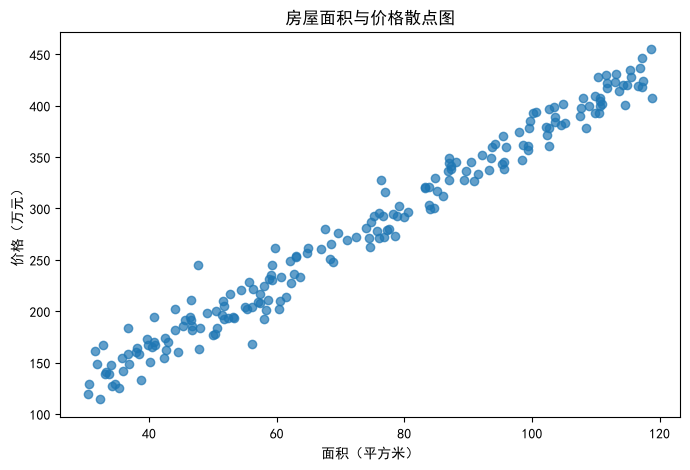

In [7]:
# ========== 2. 探索性数据分析（EDA） ==========
print("\n描述性统计：")
print(df.describe())
print("\n相关系数矩阵：")
print(df.corr())
plt.figure(figsize=(8, 5))
plt.scatter(df['面积'], df['价格'], alpha=0.7)
plt.xlabel('面积（平方米）')
plt.ylabel('价格（万元）')
plt.title('房屋面积与价格散点图')
plt.show()

In [32]:
# ========== 3. 准备特征 X 和目标 y ==========
X = df[['面积']]   # 注意：sklearn 要求 X 是二维结构
y = df['价格']
print(X)
print(y)

             面积
0     63.708611
1    115.564288
2     95.879455
3     83.879264
4     44.041678
..          ...
195   61.428862
196   95.336011
197  110.739923
198  109.837778
199  100.188799

[200 rows x 1 columns]
0      232.779767
1      427.958812
2      359.974179
3      302.862151
4      202.132489
          ...    
195    213.889059
196    342.899376
197    404.388025
198    409.095837
199    392.791140
Name: 价格, Length: 200, dtype: float64


In [9]:
#搞清楚,“‘面积’本来就是 df 数据，所以可以 [[]] 使其变为二维。”
print(type(df['面积']))
print(df['面积'].shape)

print(type(df[['面积']]))
print(df[['面积']].shape)

print(type(df['价格']))
print(df['价格'].shape)

<class 'pandas.Series'>
(200,)
<class 'pandas.DataFrame'>
(200, 1)
<class 'pandas.Series'>
(200,)


In [10]:
# ========== 4. 划分训练集和测试集 ==========
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% 作为测试集
    random_state=42     # 固定随机种子，保证结果可复现，种子不必和上面对应，此处是拆分随机种子
)
#来自于 from sklearn.model_selection import train_test_split
print(f"\n训练集样本数：{X_train.shape[0]}")
print(f"测试集样本数：{len(y_test)}") #我改了一下，说明y在此处是一维的


训练集样本数：160
测试集样本数：40


In [11]:
# ========== 5. 训练线性回归模型 ==========
model = LinearRegression()  #不是普通函数，而是创建一个模型对象
model.fit(X_train, y_train)
print("\n模型截距（intercept）：", round(model.intercept_, 2))
print("模型系数（coef）：", round(model.coef_[0], 2))
#model.coef_ 里面存放的是“每一个特征对应的系数”。有几个特征，就通常有几个系数，现在只有一个特征
print(f"拟合的回归方程：价格 = {model.intercept_:.2f} + {model.coef_[0]:.2f} * 面积")
#(f"")是 Python 的一种字符串写法。可以替换变量
print('面积系数=',model.coef_)#因为只有一个特征系数


模型截距（intercept）： 19.69
模型系数（coef）： 3.52
拟合的回归方程：价格 = 19.69 + 3.52 * 面积
面积系数= [3.5174506]


In [12]:
# ========== 6. 模型预测 ==========   #相当于是套公式
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [13]:
# ========== 7. 模型评估 ==========
def evaluate(y_true, y_pred, dataset_name):
    mae = mean_absolute_error(y_true, y_pred)  #sklearn
    mse = mean_squared_error(y_true, y_pred)   #sklearn
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{dataset_name}评估结果：")
    print(f"  MAE  (平均绝对误差): {mae:.2f}")
    print(f"  MSE  (均方误差):     {mse:.2f}")
    print(f"  RMSE (均方根误差):   {rmse:.2f}")
    print(f"  R²   (决定系数):     {r2:.4f}")
evaluate(y_train, y_train_pred, "训练集")
evaluate(y_test, y_test_pred, "测试集")
#这个函数的目的就是：计算评估指标，然后直接打印出来。它并不需要把这些指标“交还给外面”,所以不需return


训练集评估结果：
  MAE  (平均绝对误差): 11.25
  MSE  (均方误差):     202.44
  RMSE (均方根误差):   14.23
  R²   (决定系数):     0.9772

测试集评估结果：
  MAE  (平均绝对误差): 12.58
  MSE  (均方误差):     244.04
  RMSE (均方根误差):   15.62
  R²   (决定系数):     0.9702


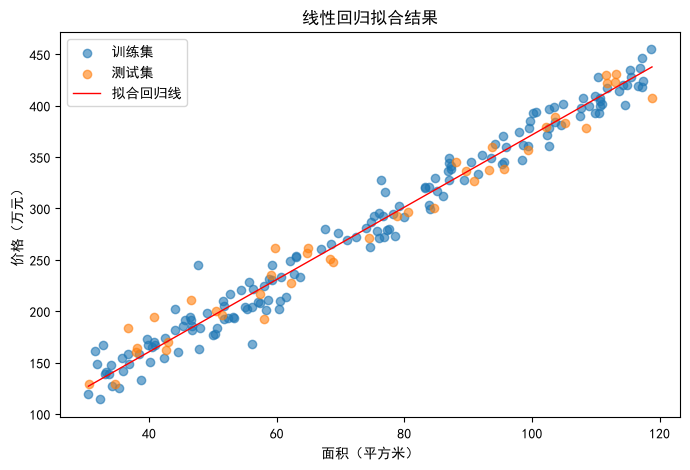

In [28]:
# ========== 8. 可视化回归线 ========== 
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, alpha=0.6, label='训练集')
plt.scatter(X_test, y_test, alpha=0.6, label='测试集')
# 生成用于画线的连续面积值
X_line = pd.DataFrame({'面积': np.linspace(X['面积'].min(),X['面积'].max(),100)}) #从最小到最大生成100个点
y_line = model.predict(X_line)
plt.plot(X_line, y_line, color='red', linewidth=1, label='拟合回归线')
plt.xlabel('面积（平方米）')
plt.ylabel('价格（万元）')
plt.title('线性回归拟合结果')
plt.legend()
plt.show()

In [34]:
# ========== 9. 预测新数据 ==========
new_areas = pd.DataFrame({'面积': [85, 100, 110]})
print(new_areas)
new_prices_pred = model.predict(new_areas)
print("\n新数据预测：")
for area_, price_ in zip(new_areas['面积'], new_prices_pred):
    print(f"面积 {area_:.0f} 平方米，预测价格约 {price_:.2f} 万元")

    面积
0   85
1  100
2  110

新数据预测：
面积 85 平方米，预测价格约 318.68 万元
面积 100 平方米，预测价格约 371.44 万元
面积 110 平方米，预测价格约 406.61 万元
